In [1]:
from pathlib import Path
import csv
import json
import gc

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sqlalchemy import create_engine, text

BASE_DIR = Path.cwd().parent
OUTPUT_CSV_METADATA_FILE = BASE_DIR / "data" / "arxiv_metadata.csv"
OUTPUT_CSV_EMBEDDING_FILE = BASE_DIR / "data" / "arxiv_embeddings.csv"

In [3]:
df = pd.read_json(BASE_DIR / "data" / "raw" / "arxiv_metadata.json", lines=True)
df = df[[
    "id", "title", "abstract", "authors", "categories",
    "comments", "journal-ref", "doi",
    "update_date", "authors_parsed",
]]

df.rename(columns={"id": "paper_id"}, inplace=True)
df["update_date"] = pd.to_datetime(df["update_date"])
df["update_year"] = df["update_date"].dt.year.astype("Int64")

In [4]:
df

,paper_id,title,abstract,authors,categories,comments,journal-ref,doi,update_date,authors_parsed,update_year
0,0704.0001,Calculation of prompt diphoton production cros...,A fully differential calculation in perturba...,"C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-...",hep-ph,"37 pages, 15 figures; published version","Phys.Rev.D76:013009,2007",10.1103/PhysRevD.76.013009,2008-11-26,"[[Balázs, C., ], [Berger, E. L., ], [Nadolsky,...",2008
1,0704.0002,Sparsity-certifying Graph Decompositions,"We describe a new algorithm, the $(k,\ell)$-...",Ileana Streinu and Louis Theran,math.CO cs.CG,To appear in Graphs and Combinatorics,NaN,NaN,2008-12-13,"[[Streinu, Ileana, ], [Theran, Louis, ]]",2008
2,0704.0003,The evolution of the Earth-Moon system based o...,The evolution of Earth-Moon system is descri...,Hongjun Pan,physics.gen-ph,"23 pages, 3 figures",NaN,NaN,2008-01-13,"[[Pan, Hongjun, ]]",2008
3,0704.0004,A determinant of Stirling cycle numbers counts...,We show that a determinant of Stirling cycle...,David Callan,math.CO,11 pages,NaN,NaN,2007-05-23,"[[Callan, David, ]]",2007
4,0704.0005,From dyadic $\Lambda_{\alpha}$ to $\Lambda_{\a...,In this paper we show how to compute the $\L...,Wael Abu-Shammala and Alberto Torchinsky,math.CA math.FA,NaN,"Illinois J. Math. 52 (2008) no.2, 681-689",NaN,2013-10-15,"[[Abu-Shammala, Wael, ], [Torchinsky, Alberto, ]]",2013
...,...,...,...,...,...,...,...,...,...,...,...
3002159,supr-con/9608008,On the origin of the irreversibility line in t...,We report on measurements of the angular dep...,"R. Prozorov, M. Konczykowski, B. Schmidt, Y. Y...",supr-con cond-mat.supr-con,"19 pages, LaTex, 6 PostScript figures; Author'...",NaN,10.1103/PhysRevB.54.15530,2009-10-30,"[[Prozorov, R., ], [Konczykowski, M., ], [Schm...",2009
3002160,supr-con/9609001,Nonlinear Response of HTSC Thin Film Microwave...,The non-linear microwave surface impedance o...,"Durga P. Choudhury, Balam A. Willemsen, John S...",supr-con cond-mat.supr-con,"4 pages, LaTeX type, Uses IEEE style files, 60...",NaN,10.1109/77.620744,2016-11-18,"[[Choudhury, Durga P., , Physics Department, N...",2016
3002161,supr-con/9609002,Critical State Flux Penetration and Linear Mic...,The vortex contribution to the dc field (H) ...,"Balam A. Willemsen, J. S. Derov and S.Sridhar ...",supr-con cond-mat.supr-con,"20 pages, LaTeX type, Uses REVTeX style files,...",NaN,10.1103/PhysRevB.56.11989,2009-10-30,"[[Willemsen, Balam A., , Physics Department,\n...",2009
3002162,supr-con/9609003,Density of States and NMR Relaxation Rate in A...,We show that the density of states in an ani...,Yasumasa Hasegawa (Himeji Institute of Technol...,supr-con cond-mat.supr-con,"7 pages, 4 PostScript Figures, LaTeX, to appea...",NaN,10.1143/JPSJ.65.3131,2009-10-30,"[[Hasegawa, Yasumasa, , Himeji Institute of Te...",2009


In [17]:
print(f"Duplicate rows based on 'paper_id' only: {df.duplicated(subset=['paper_id']).sum()}")
print(f"Duplicate rows based on 'paper_id' and 'title': {df.duplicated(subset=['paper_id', 'title']).sum()}")
print(f"Duplicate rows based on 'paper_id', 'title', and 'update_date': {df.duplicated(subset=['paper_id', 'title', 'update_date']).sum()}")
print(f"Duplicate rows based on 'paper_id', 'title', 'update_date', and 'abstract': {df.duplicated(subset=['paper_id', 'title', 'update_date', 'abstract']).sum()}")
print("")

df = df.drop_duplicates(subset=['paper_id']).reset_index(drop=True)
print(f"After dropping duplicates based on 'paper_id': {df.duplicated(subset=['paper_id']).sum()}")

Duplicate rows based on 'paper_id' only: 26
Duplicate rows based on 'paper_id' and 'title': 25
Duplicate rows based on 'paper_id', 'title', and 'update_date': 11
Duplicate rows based on 'paper_id', 'title', 'update_date', and 'abstract': 11

After dropping duplicates based on 'paper_id': 0


In [18]:
print("Number NaNs:")
print(df.isna().sum())

# no missing values for title and abstract, good!

Number NaNs:
paper_id                0
title                   0
abstract                0
authors                 0
categories              0
comments           823114
journal-ref       2062803
doi               1701635
update_date             0
authors_parsed          0
update_year             0
dtype: int64


In [19]:
print("Abstract length statistics:")
print(df["abstract"].str.strip().str.len().describe())

Abstract length statistics:


count    3.002138e+06
mean     9.927640e+02
std      4.334493e+02
min      3.000000e+00
25%      6.550000e+02
50%      9.730000e+02
75%      1.309000e+03
max      6.088000e+03
Name: abstract, dtype: float64


In [20]:
print("Categories distribution:")
print(df["categories"].value_counts().nlargest(50))
df["categories"] = df["categories"].str.split() # parse string as list of categories

Categories distribution:
categories
cs.CV                 87501
astro-ph              86900
hep-ph                85395
quant-ph              80387
hep-th                61846
cond-mat.mtrl-sci     45018
math.AP               40512
cond-mat.mes-hall     37794
cs.CL                 37676
astro-ph.GA           36529
math.CO               34906
gr-qc                 33650
cs.LG                 30913
astro-ph.SR           29409
cond-mat.str-el       28311
astro-ph.HE           26798
math.PR               26526
math.NT               25395
cs.IT math.IT         24911
astro-ph.CO           24128
math.AG               22700
math.OC               21702
cond-mat.stat-mech    20809
nucl-th               20338
cs.RO                 19746
physics.optics        19347
hep-ex                18965
math.DG               18291
cs.LG cs.AI           18200
cond-mat.supr-con     17887
cs.AI                 17357
cs.LG stat.ML         16568
astro-ph.EP           16162
math.NA cs.NA         15764
cond-mat.sof

In [21]:
print(f"Before parsing authors: {df['authors_parsed'].iloc[0]}")

# parse to list of author names -> ['Balázs C.', 'Berger E. L.', 'Nadolsky P. M.', 'Yuan C. -P.']
def parse_authors(authors):
    clean = []
    for author in authors:
        name_parts = [part.strip() for part in author[:3] if part and part.strip()] # [:3] assumes forms like ['Balázs', 'C.', '']
        clean.append(" ".join(name_parts))
    return clean

df["authors_parsed"] = df["authors_parsed"].apply(parse_authors)

print(f"After parsing authors: {df['authors_parsed'].iloc[0]}")

Before parsing authors: [['Balázs', 'C.', ''], ['Berger', 'E. L.', ''], ['Nadolsky', 'P. M.', ''], ['Yuan', 'C. -P.', '']]
After parsing authors: ['Balázs C.', 'Berger E. L.', 'Nadolsky P. M.', 'Yuan C. -P.']


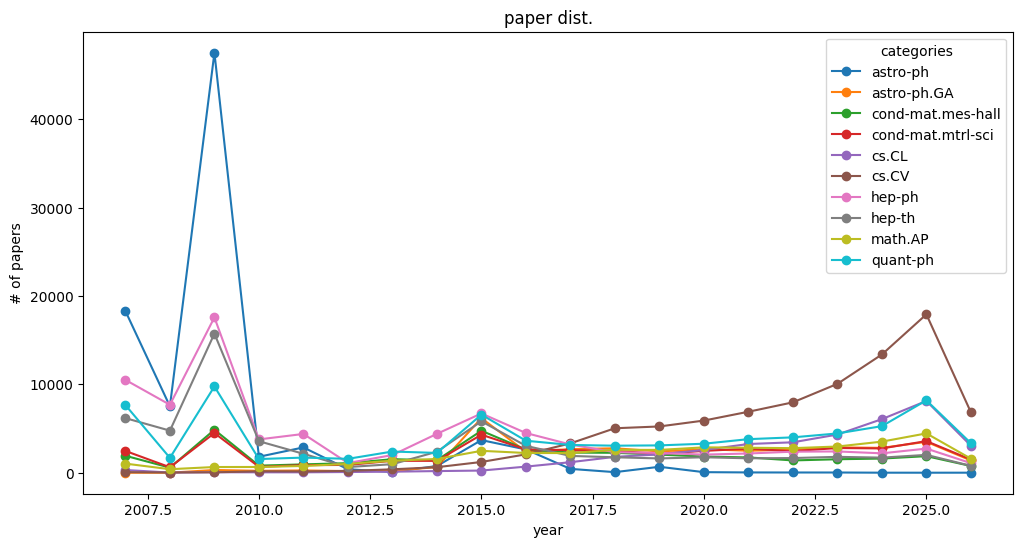

In [ ]:
# see distribution of papers over time for top categories

k = 10
top_categories = df["categories"].value_counts().nlargest(k).index
counts = (
    df[df["categories"].isin(top_categories)]
    .groupby(["update_year", "categories"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

counts.plot(figsize=(12, 6), marker="o")
plt.xlabel("year")
plt.ylabel("# of papers")
plt.title("paper dist.")
plt.show()

# make the stack chart
counts.plot(kind="bar", stacked=True, figsize=(12, 6))
plt.xlabel('year')
plt.ylabel("# of papers")
plt.show()

In [22]:
df = df[[
    "paper_id", "title", "abstract", "authors_parsed", 
    "categories", "update_year",
]]

# serialize list columns into text
df["categories"] = df["categories"].apply(json.dumps)
df["authors_parsed"] = df["authors_parsed"].apply(json.dumps)
df.rename(columns={"authors_parsed": "authors"}, inplace=True)

In [24]:
# saving only papers included in "astro-ph" category
df = df[df["categories"].str.contains("astro-ph")].reset_index(drop=True)
df.insert(0, "id", df.index)

df

,id,paper_id,title,abstract,authors,categories,update_year
0,0,0704.0009,"The Spitzer c2d Survey of Large, Nearby, Inste...",We discuss the results from the combined IRA...,"[""Harvey Paul"", ""Merin Bruno"", ""Huard Tracy L....","[""astro-ph""]",2010
1,1,0704.0017,Spectroscopic Observations of the Intermediate...,Results from spectroscopic observations of t...,"[""Mhlahlo Nceba"", ""Buckley David H."", ""Dhillon...","[""astro-ph""]",2009
2,2,0704.0023,ALMA as the ideal probe of the solar chromosphere,"The very nature of the solar chromosphere, i...","[""Loukitcheva M. A."", ""Solanki S. K."", ""White ...","[""astro-ph""]",2009
3,3,0704.0044,Astrophysical gyrokinetics: kinetic and fluid ...,We present a theoretical framework for plasm...,"[""Schekochihin A. A."", ""Cowley S. C."", ""Dorlan...","[""astro-ph"", ""nlin.CD"", ""physics.plasm-ph"", ""p...",2015
4,4,0704.0048,Inference on white dwarf binary systems using ...,We report on the analysis of selected single...,"[""Stroeer Alexander"", ""Veitch John"", ""Roever C...","[""gr-qc"", ""astro-ph""]",2008
...,...,...,...,...,...,...,...
381339,381339,quant-ph/9903043,A Possible Anisotropy in Blackbody Radiation V...,A non-local gauge symmetry of a complex scal...,"[""Dastidar T K Rai""]","[""quant-ph"", ""astro-ph"", ""hep-th""]",2007
381340,381340,quant-ph/9903053,Father Time. I. Does the Cosmic Microwave Back...,The existence of a non-thermodynamic arrow o...,"[""Dastidar T K Rai""]","[""quant-ph"", ""astro-ph"", ""hep-th""]",2009
381341,381341,quant-ph/9907088,On Bures fidelity of displaced squeezed therma...,Fidelity plays a key role in quantum informa...,"[""Wang Xiang-Bin"", ""Oh C. H."", ""Kwek L. C.""]","[""quant-ph"", ""astro-ph""]",2008
381342,381342,solv-int/9404002,Dynamical Systems Accepting the Normal Shift,Newtonian dynamical systems accepting the no...,"[""Sharipov R. A.""]","[""solv-int"", ""alg-geom"", ""astro-ph"", ""gr-qc"", ...",2008


In [25]:
df.to_csv(OUTPUT_CSV_METADATA_FILE, 
          index=False, 
          encoding="utf-8", 
          sep=",", 
          lineterminator="\n", # default for macos
          na_rep="\\N",
          escapechar="\\",
          quotechar='"',
          header=True,
          quoting=csv.QUOTE_ALL # larger size but safer for complex text fields
          )

We will only use the abstract, not title for now.

In [ ]:
# df = df[["id", "title", "abstract"]] # save memory


# # create title + abstract text for embedding
# df_embedding = pd.DataFrame({
#     "id": df["id"],
#     "text_for_embedding": 
#     "Title: " + df["title"].fillna("").str.strip() +
#     "\n\nAbstract: " + df["abstract"].fillna("").str.replace(r"\s+", " ", regex=True).str.strip()
# })

# del df
# gc.collect()

# df_embedding.to_csv(OUTPUT_CSV_EMBEDDING_FILE,
#           index=False, 
#           encoding="utf-8", 
#           sep=",", 
#           lineterminator="\n", # default for macos
#           na_rep="\\N",
#           escapechar="\\",
#           quotechar='"',
#           header=True,
#           quoting=csv.QUOTE_ALL # larger size but safer for complex text fields
#           )

0